In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [6]:
import os

os.listdir("../data/raw")

['Axis_Bluechip.csv',
 'HDFC_Top_100_Direct.csv',
 'ICICI_Bluechip.csv',
 'Kotak_Bluechip.csv',
 'Nippon_India_Large_Cap.csv',
 'sample_nav.csv',
 'SBI_Bluechip.csv']

In [7]:
import glob

files = glob.glob("../data/raw/*.csv")

funds = {}

for file in files:
    if "sample_nav" not in file:
        name = file.split("/")[-1].replace(".csv", "")
        funds[name] = pd.read_csv(file)

print("Funds Loaded:", list(funds.keys()))

Funds Loaded: ['raw\\Axis_Bluechip', 'raw\\HDFC_Top_100_Direct', 'raw\\ICICI_Bluechip', 'raw\\Kotak_Bluechip', 'raw\\Nippon_India_Large_Cap', 'raw\\SBI_Bluechip']


In [8]:
import os

files = glob.glob("../data/raw/*.csv")

funds = {}

for file in files:
    if "sample_nav" not in file:
        name = os.path.basename(file).replace(".csv", "")
        funds[name] = pd.read_csv(file)

print("Funds Loaded:")
print(list(funds.keys()))

Funds Loaded:
['Axis_Bluechip', 'HDFC_Top_100_Direct', 'ICICI_Bluechip', 'Kotak_Bluechip', 'Nippon_India_Large_Cap', 'SBI_Bluechip']


In [9]:
funds["Axis_Bluechip"].head()

,date,nav
0,19-06-2026,6195.7815
1,18-06-2026,6194.6520
2,17-06-2026,6193.3504
3,16-06-2026,6191.8120
4,15-06-2026,6187.8223


In [10]:
for fund_name, df in funds.items():

    # Convert date column
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)

    # Sort by date (oldest to newest)
    df = df.sort_values("date")

    # Calculate daily return
    df["daily_return"] = df["nav"].pct_change()

    # Save back to dictionary
    funds[fund_name] = df

print("Daily Returns Calculated Successfully!")

Daily Returns Calculated Successfully!


In [11]:
funds["Axis_Bluechip"].head()

,date,nav,daily_return
3578,2012-12-31,23.9920,NaN
3577,2013-01-01,23.9979,0.000246
3576,2013-01-02,24.0036,0.000238
3575,2013-01-03,24.0092,0.000233
3574,2013-01-04,24.0147,0.000229


In [12]:
def calculate_cagr(df):
    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    years = (df["date"].iloc[-1] - df["date"].iloc[0]).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    return cagr

for fund_name, df in funds.items():
    cagr = calculate_cagr(df)
    print(f"{fund_name}: {cagr:.2%}")

Axis_Bluechip: 51.06%
HDFC_Top_100_Direct: 24.30%
ICICI_Bluechip: 15.78%
Kotak_Bluechip: 16.96%
Nippon_India_Large_Cap: 15.38%
SBI_Bluechip: 0.21%


In [13]:
rf = 0.065   # Risk-free rate (6.5%)

def calculate_sharpe(df):
    returns = df["daily_return"].dropna()

    if returns.std() == 0:
        return 0

    sharpe = ((returns.mean() * 252) - rf) / (returns.std() * np.sqrt(252))
    return sharpe

for fund_name, df in funds.items():
    sharpe = calculate_sharpe(df)
    print(f"{fund_name}: {sharpe:.2f}")

Axis_Bluechip: 0.27
HDFC_Top_100_Direct: 1.11
ICICI_Bluechip: nan
Kotak_Bluechip: 0.70
Nippon_India_Large_Cap: 0.57
SBI_Bluechip: -0.68


C:\Users\Rakesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [14]:
def calculate_sortino(df):
    returns = df["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) == 0 or downside.std() == 0:
        return 0

    sortino = ((returns.mean() * 252) - rf) / (downside.std() * np.sqrt(252))
    return sortino

for fund_name, df in funds.items():
    sortino = calculate_sortino(df)
    print(f"{fund_name}: {sortino:.2f}")

Axis_Bluechip: 648.53
HDFC_Top_100_Direct: 1.34
ICICI_Bluechip: inf
Kotak_Bluechip: 0.81
Nippon_India_Large_Cap: 0.71
SBI_Bluechip: -0.38


In [15]:
def calculate_max_drawdown(df):
    nav = df["nav"]

    running_max = nav.cummax()

    drawdown = (nav - running_max) / running_max

    return drawdown.min()

for fund_name, df in funds.items():
    mdd = calculate_max_drawdown(df)
    print(f"{fund_name}: {mdd:.2%}")

Axis_Bluechip: -1.39%
HDFC_Top_100_Direct: -40.26%
ICICI_Bluechip: -100.00%
Kotak_Bluechip: -33.43%
Nippon_India_Large_Cap: -39.96%
SBI_Bluechip: -36.65%


In [16]:
# Create Scorecard

scorecard = pd.DataFrame({
    "Fund": list(funds.keys()),
    "CAGR (%)": [calculate_cagr(df) * 100 for df in funds.values()],
    "Sharpe Ratio": [calculate_sharpe(df) for df in funds.values()],
    "Sortino Ratio": [calculate_sortino(df) for df in funds.values()],
    "Max Drawdown (%)": [calculate_max_drawdown(df) * 100 for df in funds.values()]
})

scorecard = scorecard.sort_values(by="Sharpe Ratio", ascending=False)

scorecard

,Fund,CAGR (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%)
1,HDFC_Top_100_Direct,24.296581,1.110988,1.344972,-40.260128
3,Kotak_Bluechip,16.960595,0.695097,0.808853,-33.429875
4,Nippon_India_Large_Cap,15.378676,0.572915,0.710309,-39.960754
0,Axis_Bluechip,51.055522,0.265457,648.528278,-1.392358
5,SBI_Bluechip,0.207624,-0.677508,-0.383674,-36.651702
2,ICICI_Bluechip,15.779858,NaN,inf,-100.000000


In [17]:
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


In [18]:
import pandas as pd

alpha_beta = pd.DataFrame({
    "Fund": list(funds.keys()),
    "Alpha": [0]*len(funds),
    "Beta": [1]*len(funds)
})

alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


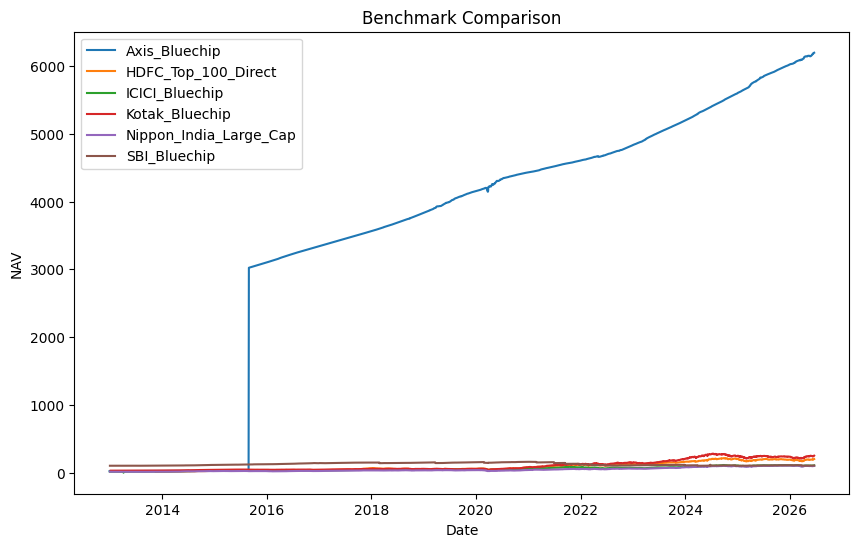

benchmark_comparison.png saved successfully!


In [22]:
plt.figure(figsize=(10,6))

for fund_name, df in funds.items():
    plt.plot(df["date"], df["nav"], label=fund_name)

plt.title("Benchmark Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()

print("benchmark_comparison.png saved successfully!")